# Twitter Emotion-Aware Sentiment Classification Using Machine Learning Techniques

## Project Overview
This project focuses on sentiment and emotion-aware classification of Twitter text using Natural Language Processing (NLP) and Machine Learning techniques. The system preprocesses tweet data, extracts TF-IDF features, and applies multiple machine learning algorithms for sentiment classification.

## Objectives
- Perform text preprocessing on Twitter data
- Convert text into numerical features using TF-IDF
- Train machine learning models
- Compare model performances
- Evaluate classification accuracy

## Algorithms Used
- Naive Bayes
- Support Vector Machine (SVM)
- Logistic Regression

In [4]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np
import re

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Natural Language Processing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# Download NLTK Resources
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\arghaanjahangir\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\arghaanjahangir\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# Dataset Loading and Exploration

In [5]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("tweet_emotions.csv")

print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(40000, 3)


In [6]:
# ==========================================
# Display First 5 Rows
# ==========================================

df.head()

,tweet_id,sentiment,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,@dannycastillo We want to trade with someone w...


In [7]:
# ==========================================
# Dataset Information
# ==========================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet_id   40000 non-null  int64 
 1   sentiment  40000 non-null  object
 2   content    40000 non-null  object
dtypes: int64(1), object(2)
memory usage: 937.6+ KB


In [8]:
# ==========================================
# Emotion Distribution
# ==========================================

df['sentiment'].value_counts()

sentiment
neutral       8638
worry         8459
happiness     5209
sadness       5165
love          3842
surprise      2187
fun           1776
relief        1526
hate          1323
empty          827
enthusiasm     759
boredom        179
anger          110
Name: count, dtype: int64

# Data Preprocessing

In [10]:
# ==========================================
# Initialize NLP Tools
# ==========================================

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [11]:
# ==========================================
# Text Cleaning Function
# ==========================================

def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove usernames
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags
    text = re.sub(r'#\w+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = text.split()

    # Remove short words
    words = [word for word in words if len(word) > 2]

    # Remove stopwords and apply lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [12]:
# ==========================================
# Apply Text Cleaning
# ==========================================

df['clean_text'] = df['content'].apply(clean_text)

# ==========================================
# Display Original and Cleaned Text
# ==========================================

df[['content', 'clean_text']].head()

In [14]:
# ==========================================
# Remove Duplicate Rows
# ==========================================

df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates:")
print(df.shape)

Dataset Shape After Removing Duplicates:
(40000, 4)


In [15]:
# Sentiment Grouping

In [16]:
# ==========================================
# Group Emotions into Sentiment Classes
# ==========================================

emotion_mapping = {

    'happiness': 'positive',
    'love': 'positive',

    'sadness': 'negative',
    'worry': 'negative',

    'neutral': 'neutral'
}

# Keep selected emotions only
df = df[df['sentiment'].isin(emotion_mapping.keys())]

# Apply mapping
df['sentiment'] = df['sentiment'].map(emotion_mapping)

In [17]:
# ==========================================
# Final Sentiment Distribution
# ==========================================

df['sentiment'].value_counts()

sentiment
negative    13624
positive     9051
neutral      8638
Name: count, dtype: int64

# TF-IDF Feature Extraction

In [18]:
# ==========================================
# TF-IDF Feature Extraction
# ==========================================

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)

X = tfidf.fit_transform(df['clean_text'])

y = df['sentiment']

print("TF-IDF Feature Shape:")
print(X.shape)

TF-IDF Feature Shape:
(31313, 10000)


# Train-Test Split

In [19]:
# ==========================================
# Split Dataset into Training and Testing Data
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (25050, 10000)
Testing Data Shape: (6263, 10000)


# Machine Learning Model Training

In [20]:
# ==========================================
# Train Naive Bayes Model
# ==========================================

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Accuracy:")
print(accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy:
0.5725690563627654


In [21]:
# ==========================================
# Train Support Vector Machine (SVM)
# ==========================================

svm_model = LinearSVC(C=10)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:")
print(accuracy_score(y_test, svm_pred))

SVM Accuracy:
0.5323327478844004


In [22]:
# ==========================================
# Train Logistic Regression Model
# ==========================================

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy:
0.5971579115439885


# Model Comparison

In [23]:
# ==========================================
# Model Accuracy Comparison
# ==========================================

results = pd.DataFrame({

    'Model': [
        'Naive Bayes',
        'SVM',
        'Logistic Regression'
    ],

    'Accuracy': [

        accuracy_score(y_test, nb_pred),

        accuracy_score(y_test, svm_pred),

        accuracy_score(y_test, lr_pred)
    ]
})

results

,Model,Accuracy
0,Naive Bayes,0.572569
1,SVM,0.532333
2,Logistic Regression,0.597158


# Model Evaluation and Visualization

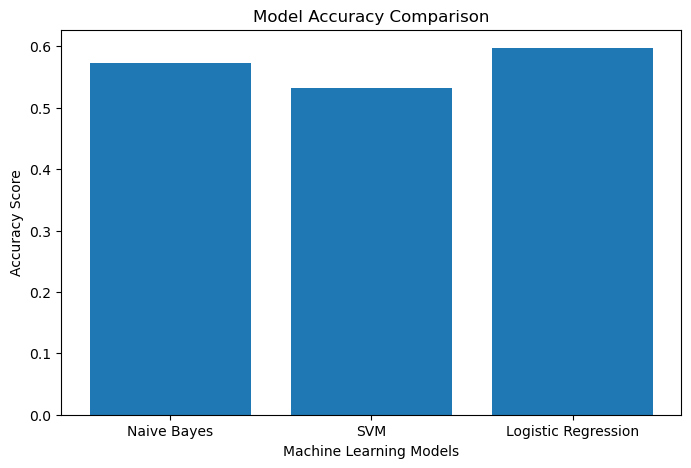

In [25]:
# ==========================================
# Accuracy Comparison Graph
# ==========================================

models = results['Model']
accuracies = results['Accuracy']

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy Score")
plt.title("Model Accuracy Comparison")

# Save graph
plt.savefig("accuracy_graph.png")

plt.show()

# Confusion Matrix Visualization

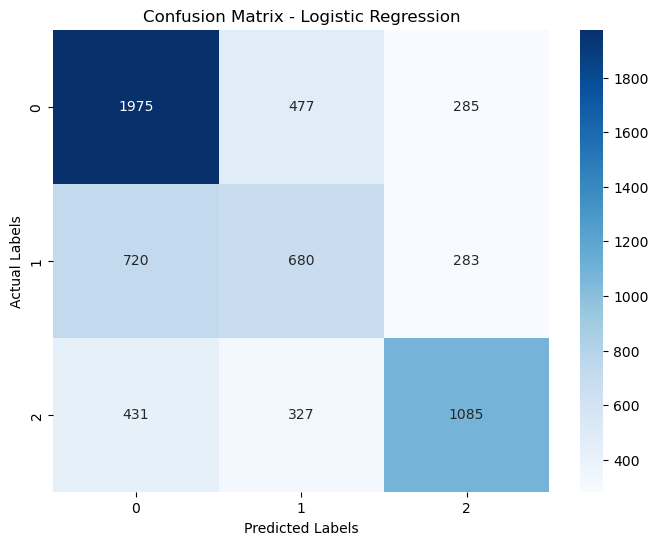

In [26]:
# ==========================================
# Confusion Matrix - Logistic Regression
# ==========================================

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")

# Save image
plt.savefig("confusion_matrix.png")

plt.show()

# Classification Report

In [27]:
# ==========================================
# Logistic Regression Classification Report
# ==========================================

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

    negative       0.63      0.72      0.67      2737
     neutral       0.46      0.40      0.43      1683
    positive       0.66      0.59      0.62      1843

    accuracy                           0.60      6263
   macro avg       0.58      0.57      0.57      6263
weighted avg       0.59      0.60      0.59      6263



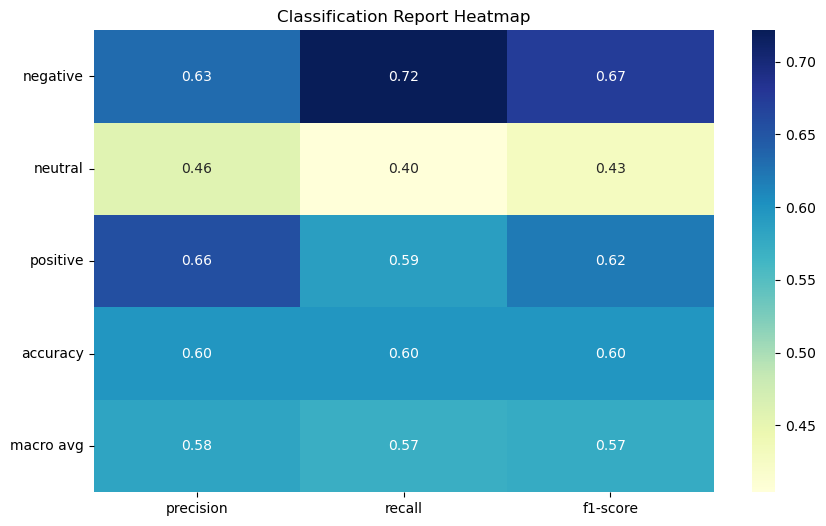

In [30]:
# ==========================================
# Visual Classification Report Heatmap
# ==========================================

from sklearn.metrics import classification_report
import pandas as pd

# Generate classification report dictionary
report = classification_report(
    y_test,
    lr_pred,
    output_dict=True
)

# Convert to DataFrame
report_df = pd.DataFrame(report).transpose()

# Create heatmap visualization
plt.figure(figsize=(10,6))

sns.heatmap(
    report_df.iloc[:-1, :-1],
    annot=True,
    cmap='YlGnBu',
    fmt='.2f'
)

plt.title("Classification Report Heatmap")
plt.yticks(rotation=0)

# Save image
plt.savefig("classification_report_heatmap.png")

plt.show()

# ROC Curve Analysis

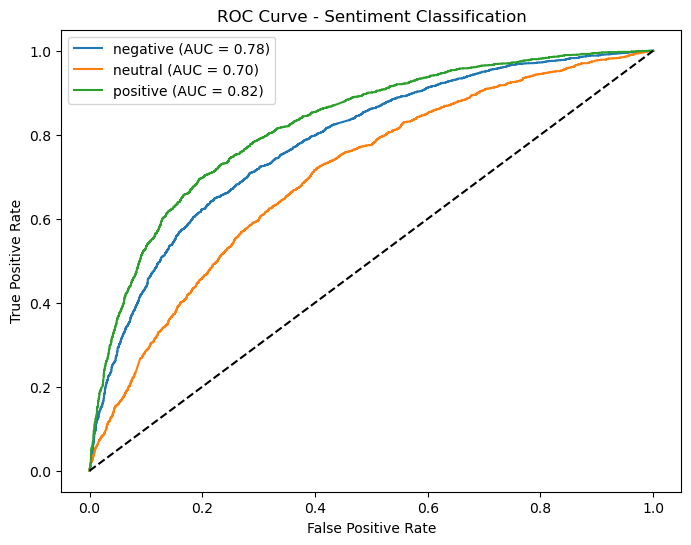

In [28]:
# ==========================================
# ROC Curve Analysis
# ==========================================

from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# Convert labels into binary format
classes = y.unique()

y_bin = label_binarize(y, classes=classes)

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X,
    y_bin,
    test_size=0.2,
    random_state=42
)

# Train One-vs-Rest Logistic Regression
model = OneVsRestClassifier(
    LogisticRegression(max_iter=1000)
)

model.fit(X_train_bin, y_train_bin)

# Predict probabilities
y_score = model.predict_proba(X_test_bin)

# Plot ROC Curves
plt.figure(figsize=(8,6))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'{classes[i]} (AUC = {roc_auc:.2f})'
    )

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Sentiment Classification")

plt.legend()

# Save ROC image
plt.savefig("roc_curve.png")

plt.show()